# Fine-Tunning Pretrained Model :-

We will learn following in this chapter :-

* How to prepare a large dataset from the Hub using the latest `🤗 Datasets` features

* How to use the high-level `Trainer` API to fine-tune a model with modern best practices

* How to implement a custom `training loop` with optimization techniques

* How to leverage the 🤗 Accelerate library to easily run distributed training on any setup

* How to apply current fine-tuning best practices for maximum performance

## Processing the data :-

In this section we will use as an example the `MRPC (Microsoft Research Paraphrase Corpus) dataset`, introduced in a paper by William B. Dolan and Chris Brockett. The dataset consists of **5,801 pairs of sentences**, with a label indicating if they are **paraphrases** or not (i.e., if both sentences mean the same thing). We’ve selected it for this chapter because it’s a small dataset, so it’s easy to experiment with training on it.

#### Loading a dataset from the Hub :-

The Hub doesn’t just contain models; it also has multiple datasets in lots of different languages. You can browse the datasets on Hub. For now, let’s focus on the `MRPC dataset!` This is one of the 10 datasets composing the GLUE benchmark, which is an academic benchmark that is used to measure the performance of ML models across 10 different text classification tasks.

The 🤗 Datasets library provides a very simple command to download and cache a dataset on the Hub. We can download the MRPC dataset like this:

In [1]:
from datasets import load_dataset

raw_datasets = load_dataset("nyu-mll/glue", "mrpc")    # 
raw_datasets

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

`nyu-mll/glue` is the proper `namespace/name` format that newer versions of the library expect — the old shorthand "glue" doesn't works anymore

`DatasetDict` is a **dictionary-like object** where each key is a split of the dataset and each value is a `Dataset object` (think of it like a table):

* `train` → data used to train the model (3,668 rows)

* `validation` → data used to check performance during training (408 rows)

* `test` → data used for final evaluation after training (1,725 rows)

We can access each pair of sentences in our raw_datasets object by indexing, like with a dictionary:

In [2]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [3]:
import pandas as pd
pd.DataFrame(raw_datasets["train"])

,sentence1,sentence2,label,idx
0,"Amrozi accused his brother , whom he called "" ...","Referring to him as only "" the witness "" , Amr...",1,0
1,Yucaipa owned Dominick 's before selling the c...,Yucaipa bought Dominick 's in 1995 for $ 693 m...,0,1
2,They had published an advertisement on the Int...,"On June 10 , the ship 's owners had published ...",1,2
3,"Around 0335 GMT , Tab shares were up 19 cents ...","Tab shares jumped 20 cents , or 4.6 % , to set...",0,3
4,"The stock rose $ 2.11 , or about 11 percent , ...",PG & E Corp. shares jumped $ 1.63 or 8 percent...,1,4
...,...,...,...,...
3663,""" At this point , Mr. Brando announced : ' Som...","Brando said that "" somebody ought to put a bul...",1,4071
3664,"Martin , 58 , will be freed today after servin...",Martin served two thirds of a five-year senten...,0,4072
3665,""" We have concluded that the outlook for price...","In a statement , the ECB said the outlook for ...",1,4073
3666,The notification was first reported Friday by ...,MSNBC.com first reported the CIA request on Fr...,1,4074


We can see the labels are already integers, so we won’t have to do any preprocessing there. To know which integer corresponds to which label, we can inspect the `features` of our `raw_train_dataset`. This will tell us the type of each column:

In [4]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

Behind the scenes, `label` is of type `ClassLabel`, and the mapping of integers to label name is stored in the names folder. `0` corresponds to `not_equivalent`, and `1` corresponds to `equivalent`.

#### Preprocessing a dataset :-

To **preprocess the dataset**, we need to convert the **text to numbers** the model can make sense of. This is done with a `tokenizer`. We can feed the tokenizer one sentence or a list of sentences, so we can directly tokenize all the first sentences and all the second sentences of each pair like this:

In [5]:
from transformers import AutoTokenizer

checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

tokenized_sentences_1 = tokenizer(list(raw_datasets["train"]["sentence1"]))
tokenized_sentences_2 = tokenizer(list(raw_datasets["train"]["sentence2"]))

Converted into list because `raw_datasets["train"]["sentence1"]` is returning a dataset column object, not a plain Python list. The tokenizer expects a list of strings.

In [6]:
tokenized_sentences_1

{'input_ids': [[101, 2572, 3217, 5831, 5496, 2010, 2567, 1010, 3183, 2002, 2170, 1000, 1996, 7409, 1000, 1010, 1997, 9969, 4487, 23809, 3436, 2010, 3350, 1012, 102], [101, 9805, 3540, 11514, 2050, 3079, 11282, 2243, 1005, 1055, 2077, 4855, 1996, 4677, 2000, 3647, 4576, 1999, 2687, 2005, 1002, 1016, 1012, 1019, 4551, 1012, 102], [101, 2027, 2018, 2405, 2019, 15147, 2006, 1996, 4274, 2006, 2238, 2184, 1010, 5378, 1996, 6636, 2005, 5096, 1010, 2002, 2794, 1012, 102], [101, 2105, 6021, 19481, 13938, 2102, 1010, 21628, 6661, 2020, 2039, 2539, 16653, 1010, 2030, 1018, 1012, 1018, 1003, 1010, 2012, 1037, 1002, 1018, 1012, 5179, 1010, 2383, 3041, 2275, 1037, 2501, 2152, 1997, 1037, 1002, 1018, 1012, 5401, 1012, 102], [101, 1996, 4518, 3123, 1002, 1016, 1012, 2340, 1010, 2030, 2055, 2340, 3867, 1010, 2000, 2485, 5958, 2012, 1002, 2538, 1012, 4868, 2006, 1996, 2047, 2259, 4518, 3863, 1012, 102], [101, 6599, 1999, 1996, 2034, 4284, 1997, 1996, 2095, 3333, 2321, 3867, 2013, 1996, 2168, 2558, 1037,

However, we can’t just pass two sequences to the model and get a prediction of whether the two sentences are paraphrases or not. We need to handle the two sequences as a pair, and apply the appropriate preprocessing. Fortunately, the tokenizer can also take a pair of sequences and prepare it the way our BERT model expects:

In [7]:
inputs = tokenizer("This is the first sentence.", "This is the second one.")
inputs

{'input_ids': [101, 2023, 2003, 1996, 2034, 6251, 1012, 102, 2023, 2003, 1996, 2117, 2028, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

We put off talking about `token_type_ids`. In this example, this is what tells the model which part of the input is the first sentence and which is the second sentence.

If we decode the IDs inside `input_ids` back to words:

In [8]:
print(tokenizer.convert_ids_to_tokens(inputs["input_ids"]))    # used print to force horizontal outpot as without it the long list will be shown vertically

['[CLS]', 'this', 'is', 'the', 'first', 'sentence', '.', '[SEP]', 'this', 'is', 'the', 'second', 'one', '.', '[SEP]']


So we see the model expects the inputs to be of the form `[CLS] sentence1 [SEP] sentence2 [SEP]` when there are two sentences. Aligning this with the `token_type_ids` gives us:

['[CLS]', 'this', 'is', 'the', 'first', 'sentence', '.', '[SEP]', 'this', 'is', 'the', 'second', 'one', '.', '[SEP]']

[      0,      0,    0,     0,       0,          0,   0,       0,      1,    1,     1,        1,     1,   1,       1]

As you can see, the parts of the input corresponding to `[CLS] sentence1 [SEP]` all have a token type ID of `0`, while the other parts, corresponding to `sentence2 [SEP]`, all have a token type ID of `1`.

Note that if you select a different checkpoint, you won’t necessarily have the `token_type_ids` in your tokenized inputs (for instance, they’re not returned if you use a `DistilBERT model`). They are only returned when the model will know what to do with them, because it has seen them during its pretraining.

Here, BERT is pretrained with token type IDs, and on top of the **masked language modeling objective**, it has an additional objective called **next sentence prediction**. The goal with this task is to model the relationship between pairs of sentences.

With next sentence prediction, the model is provided pairs of sentences (with randomly masked tokens) and asked to predict whether the second sentence follows the first. To make the task non-trivial, half of the time the sentences follow each other in the original document they were extracted from, and the other half of the time the two sentences come from two different documents.

In general, you don’t need to worry about whether or not there are `token_type_ids` in your tokenized inputs: as long as you use the same checkpoint for the tokenizer and the model, everything will be fine as the tokenizer knows what to provide to its model.

Now that we have seen how our tokenizer can deal with one pair of sentences, we can use it to tokenize our whole dataset: we can feed the tokenizer a list of pairs of sentences by giving it the list of first sentences, then the list of second sentences. This is also compatible with the padding and truncation options. So, one way to preprocess the training dataset is:

In [9]:
tokenized_dataset = tokenizer(
    list(raw_datasets["train"]["sentence1"]),
    list(raw_datasets["train"]["sentence2"]),
    padding=True,
    truncation=True
)

This works well, but it has the disadvantage of returning a dictionary (with our keys, `input_ids`, `attention_mask`, and `token_type_ids`, and values that are lists of lists). It will also only work if you have enough RAM to store your whole dataset during the tokenization (whereas the datasets from the 🤗 Datasets library are **Apache Arrow files** stored on the disk, so you only keep the samples you ask for loaded in memory).

To keep the data as a dataset, we will use the `Dataset.map()` method. This also allows us some extra flexibility, if we need more preprocessing done than just tokenization. The `map()` method works by applying a function on each element of the dataset, so let’s define a function that tokenizes our inputs:

In [10]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

This function takes a dictionary (like the items of our dataset) and returns a new dictionary with the keys `input_ids`, `attention_mask`, and `token_type_ids`. Note that it also works if the `example` dictionary contains several samples (each key as a list of sentences) since the `tokenizer` works on lists of pairs of sentences, as seen before. This will allow us to use the option `batched=True` in our call to `map()`, which will greatly speed up the tokenization. The `tokenizer` is backed by a tokenizer written in Rust from the 🤗 Tokenizers library. This tokenizer can be very fast, but only if we give it lots of inputs at once.

> Note that we’ve left the `padding` argument out in our tokenization function for now. This is because padding all the samples to the maximum length is not efficient: it’s better to pad the samples when we’re building a `batch`, as then we only need to pad to the maximum length in that batch, and not the maximum length in the entire dataset. This can save a lot of time and processing power when the inputs have very variable lengths!

**Doubt Clearer:** The tokenizer finds the longest sequence in the whole dataset (say `128 tokens`) and pads **EVERYTHING** to `128` — even a sentence that's only 5 tokens gets padded to 128. That's why instead of using padding on the **whole dataset** we use it while `batching`.

Here is how we apply the tokenization function on all our datasets at once. We’re using `batched=True` in our call to `map` so the function is applied to multiple elements of our dataset at once, and not on each element separately. This allows for faster preprocessing.

In [11]:
tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

The way the 🤗 Datasets library applies this processing is by adding new fields to the datasets, one for each key in the dictionary returned by the preprocessing function.

You can even use multiprocessing when applying your preprocessing function with `map()` by passing along a `num_proc` argument. We didn’t do this here because the 🤗 Tokenizers library already uses multiple threads to tokenize our samples faster, but if you are not using a fast tokenizer backed by this library, this could speed up your preprocessing.

Our `tokenize_function` returns a dictionary with the keys `input_ids`, `attention_mask`, and `token_type_ids`, so those three fields are added to all splits of our dataset. Note that we could also have changed existing fields if our preprocessing function returned a new value for an existing key in the dataset to which we applied `map()`.

The last thing we will need to do is pad all the examples to the length of the longest element when we batch elements together — a technique we refer to as `dynamic padding`.

#### Dynamic Padding :-

The function that is responsible for putting together samples inside a batch is called a collate function. It’s an argument you can pass when you build a `DataLoader`, the default being a function that will just convert your samples to PyTorch tensors and concatenate them (recursively if your elements are lists, tuples, or dictionaries). This won’t be possible in our case since the inputs we have won’t all be of the same size. We have deliberately postponed the padding, to only apply it as necessary on each batch and avoid having over-long inputs with a lot of padding. This will speed up training by quite a bit, but note that if you’re training on a TPU it can cause problems — TPUs prefer fixed shapes, even when that requires extra padding.

To do this in practice, we have to define a collate function that will apply the correct amount of padding to the items of the dataset we want to batch together. Fortunately, the 🤗 Transformers library provides us with such a function via `DataCollatorWithPadding`. It takes a tokenizer when you instantiate it (to know which padding token to use, and whether the model expects padding to be on the left or on the right of the inputs) and will do everything you need:

In [12]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

To test this new toy, let’s grab a few samples from our training set that we would like to batch together. Here, we remove the columns `idx`, `sentence1`, and `sentence2` as they won’t be needed and contain strings (and we can’t create tensors with strings) and have a look at the lengths of each entry in the batch:

In [13]:
samples = tokenized_datasets["train"][:8]
samples = {k: v for k, v in samples.items() if k not in ["idx", "sentence1", "sentence2"]}

[len(x) for x in samples["input_ids"]]

[50, 59, 47, 67, 59, 50, 62, 32]

No surprise, we get samples of varying length, from 32 to 67. Dynamic padding means the samples in this batch should all be padded to a length of 67, the maximum length inside the batch. Without dynamic padding, all of the samples would have to be padded to the maximum length in the whole dataset, or the maximum length the model can accept. Let’s double-check that our `data_collator` is dynamically padding the batch properly:

In [14]:
batch = data_collator(samples)
{k: v.shape for k, v in batch.items()}

{'input_ids': torch.Size([8, 67]),
 'token_type_ids': torch.Size([8, 67]),
 'attention_mask': torch.Size([8, 67]),
 'labels': torch.Size([8])}

Looking good! Now that we’ve gone from raw text to batches our model can deal with, we’re ready to fine-tune it!

> Perfect! Now that we have preprocessed our data with the latest best practices from the 🤗 Datasets library, we’re ready to move on to training our model using the modern Trainer API. Now we will see how to fine-tune your model effectively using the latest features and optimizations available in the Hugging Face ecosystem.

## Fine-tuning a model with the Trainer API :-

🤗 Transformers provides a `Trainer` class to help you fine-tune any of the pretrained models it provides on your dataset with modern best practices. Once you’ve done all the data preprocessing work in the last section, you have just a few steps left to define the `Trainer`. The hardest part is likely to be preparing the environment to run `Trainer.train()`, as it will run very slowly on a CPU. If you don’t have a GPU set up

Here is a short summary recapping what you need:

In [15]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("nyu-mll/glue", "mrpc")
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)


tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

### Training :-

The first step before we can define our `Trainer` is to define a `TrainingArguments` class that will contain all the hyperparameters the `Trainer` will use for training and evaluation. The only argument you have to provide is a directory where the trained model will be saved, as well as the checkpoints along the way. For all the rest, you can leave the defaults, which should work pretty well for a basic fine-tuning.

In [16]:
from transformers import TrainingArguments

training_args = TrainingArguments("test-trainer")

The second step is to define our model. We will again use the `AutoModelForSequenceClassification` class, with two labels:

In [17]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9061.53it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

You will notice that unlike in Chapter 2, you get a warning after instantiating this pretrained model. This is because BERT has not been pretrained on classifying pairs of sentences, so the head of the pretrained model has been discarded and a new head suitable for sequence classification has been added instead. The warnings indicate that some weights were not used (the ones corresponding to the dropped pretraining head) and that some others were randomly initialized (the ones for the new head). It concludes by encouraging you to train the model, which is exactly what we are going to do now.

Once we have our `model`, we can define a `Trainer` by passing it all the objects constructed up to now — the `model`, the `training_args`, the `training and validation datasets`, our `data_collator`, and our `processing_class`. The `processing_class` parameter is a newer addition that tells the Trainer which tokenizer to use for processing:

In [18]:
from transformers import Trainer

trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
)

When you pass a tokenizer as the `processing_class`, the default `data_collator` used by the `Trainer` will be a `DataCollatorWithPadding`. You can skip the `data_collator=data_collator` line in this case, but we included it here to show you this important part of the processing pipeline.

To **fine-tune** the model on our dataset, we just have to call the `train()` method of our `Trainer`:

In [19]:
trainer.train()

Step,Training Loss
500,0.507750
1000,0.271260


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.09it/s]


TrainOutput(global_step=1377, training_loss=0.32098160122474556, metrics={'train_runtime': 133.8826, 'train_samples_per_second': 82.191, 'train_steps_per_second': 10.285, 'total_flos': 405114969714960.0, 'train_loss': 0.32098160122474556, 'epoch': 3.0})

This will start the fine-tuning (which should take a couple of minutes on a GPU) and report the training loss every 500 steps. It won’t, however, tell you how well (or badly) your model is performing. This is because:

1. We didn’t tell the `Trainer to evaluate during training by setting `eval_strategy` in `TrainingArguments` to either `"steps"` (evaluate every `eval_steps`) or `"epoch"` (evaluate at the end of each epoch).

2. We didn’t provide the `Trainer` with a `compute_metrics()` function to calculate a metric during said evaluation (otherwise the evaluation would just have printed the loss, which is not a very intuitive number).

## Evaluation :-

Let’s see how we can build a useful `compute_metrics()` function and use it the next time we train. The function must take an `EvalPrediction` object (which is a named tuple with a `predictions` field and a `label_ids` field) and will return a dictionary mapping strings to floats (the strings being the names of the metrics returned, and the floats their values). To get some predictions from our model, we can use the `Trainer.predict()` command:

In [20]:
predictions = trainer.predict(tokenized_datasets["validation"])
print(predictions.predictions.shape, predictions.label_ids.shape)

(408, 2) (408,)


predictions.predictions.shape = 408 rows and 2 columns

The reason we pass tokenized data while predicting instead of raw sentences is because the `Trainer` works at a low level — it expects data in the same format it was trained on (tokenized, not raw text). It's not a user-facing tool, it's a training/evaluation tool.

The output of the `predict()` method is another named tuple with three fields: `predictions`, `label_ids`, and `metrics`. The `metrics` field will just contain the loss on the dataset passed, as well as some time metrics (how long it took to predict, in total and on average). Once we complete our `compute_metrics()` function and pass it to the `Trainer`, that field will also contain the metrics returned by `compute_metrics()`.

As you can see, `predictions` is a two-dimensional array with shape 408 x 2 (408 being the number of elements in the dataset we used). Those are the logits for each element of the dataset we passed to `predict()`, all Transformer models return logits). To transform them into predictions that we can compare to our labels, we need to take the index with the maximum value on the second axis:

In [21]:
import numpy as np

preds = np.argmax(predictions.predictions, axis=-1)

We can now compare those `preds` to the labels. To build our `compute_metric()` function, we will rely on the metrics from the **🤗 Evaluate library**. We can load the metrics associated with the MRPC dataset as easily as we loaded the dataset, this time with the `evaluate.load()` function. The object returned has a `compute()` method we can use to do the metric calculation:

In [22]:
import evaluate

metric = evaluate.load("glue", "mrpc")
metric.compute(predictions=preds, references=predictions.label_ids)

{'accuracy': 0.8357843137254902, 'f1': 0.8866328257191202}

The exact results you get may vary, as the random initialization of the model head might change the metrics it achieved. Here, we can see our model has an accuracy of 86.27% on the validation set and an F1 score of 90.50%. Those are the two metrics used to evaluate results on the MRPC dataset for the GLUE benchmark. The table in the BERT paper reported an F1 score of 88.9 for the base model. That was the `uncased` model while we are currently using the `cased` model, which explains the better result.

Wrapping everything together, we get our `compute_metrics()` function:

In [23]:
def compute_metrics(eval_preds):
    metric = evaluate.load("glue", "mrpc")
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

And to see it used in action to report metrics at the end of each epoch, here is how we define a new `Trainer` with this `compute_metrics()` function:

In [24]:
training_args = TrainingArguments("test-trainer", eval_strategy="epoch")
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4352.03it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Note that we create a new `TrainingArguments` with its `eval_strategy` set to `"epoch"` and a new model — otherwise, we would just be continuing the training of the model we have already trained. To launch a new training run, we execute:

In [25]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.339523,0.865196,0.906303
2,0.513550,0.510224,0.852941,0.896194
3,0.253726,0.689131,0.860294,0.901554


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s]


TrainOutput(global_step=1377, training_loss=0.30880697412428515, metrics={'train_runtime': 286.4567, 'train_samples_per_second': 38.414, 'train_steps_per_second': 4.807, 'total_flos': 405114969714960.0, 'train_loss': 0.30880697412428515, 'epoch': 3.0})

This time, it will report the validation loss and metrics at the end of each epoch on top of the training loss. Again, the exact accuracy/F1 score you reach might be a bit different from what we found, because of the random head initialization of the model, but it should be in the same ballpark.

#### Advanced Training Features :-

The `Trainer` comes with many built-in features that make modern deep learning best practices accessible:

**Mixed Precision Training:** Use fp16=True in your training arguments for faster training and reduced memory usage

`Mixed Precision Training:` It is a technique where instead of using `32-bit floating point numbers (fp32)` for all calculations during training, you use `16-bit floating point (fp16)` for most operations and keep 32-bit only where precision is critical.

**Result:** 2x less memory usage + significantly faster training because GPUs handle 16-bit math much faster than 32-bit, with minimal impact on model accuracy.

In [26]:
training_args = TrainingArguments(
    "test-trainer",
    eval_strategy="epoch",
    fp16=True
)

**Gradient Accumulation:** For effective larger batch sizes when GPU memory is limited:

`Gradient Accumulation:` It is a technique where instead of updating model weights after every single batch, you **accumulate (sum up) gradients over multiple batches and update once**.

For example with `gradient_accumulation_steps=4` — you process 4 batches, add up their gradients, then do one weight update. This effectively simulates a batch size 4x larger without needing 4x more GPU memory.

Useful when your GPU can't fit a large batch size in memory but you still want the training stability benefits of large batches.

In [27]:
training_args = TrainingArguments(
    "test-trainer",
    eval_strategy="epoch",
    per_device_train_batch_size=4,   # process 4 sentences(batch_size=4) at a time on each GPU/CPU during training, per_device means this is the batch size per device — if you have 2 GPUs, total batch size would be 4×2=8
    gradient_accumulation_steps=4,  # Effective batch size = 4 * 4 = 16
)

**Learning Rate Scheduling:** The Trainer uses linear decay by default, but you can customize this:

`learning_rate=2e-5` - Controls how big the weight updates are during training. `2e-5` means `0.00002` — very small, which is intentional for fine-tuning. You don't want large updates because the model is already pretrained and you just want to slightly adjust the weights, not completely overwrite what it learned.

In [28]:
training_args = TrainingArguments(
    "test-trainer",
    eval_strategy="epoch",
    learning_rate=2e-5,
    lr_scheduler_type="cosine",  # Try different schedulers
)

`lr_scheduler_type="cosine"` - Instead of keeping the learning rate fixed throughout training, a scheduler changes it over time. Cosine scheduler specifically:

* Starts at your set learning rate (`2e-5`)

* Gradually decreases it following a cosine curve

* Ends near zero by the end of training

The idea is — in early training you want bigger steps to learn fast, in later training you want smaller steps to fine-tune precisely without overshooting. Cosine is just a smooth way to do that decrease.

The `Trainer` will work out of the box on multiple GPUs or TPUs and provides lots of options for distributed training. We will go over everything it supports in Chapter 10.

This concludes the introduction to fine-tuning using the `Trainer API`. An example of doing this for most common NLP tasks will be given in Chapter 7, but for now let’s look at how to do the same thing with a pure PyTorch training loop.

`Note:` Evaluation is optional - you can train without it, but you won't see validation metrics.

# A Full Training Loop :-

Now we’ll see how to achieve the same results as we did in the last section without using the Trainer class, implementing a training loop from scratch with modern PyTorch best practices. Here is a short summary covering everything we will need:

In [29]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("nyu-mll/glue", "mrpc")
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)


tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Prepare for training :-

Before actually writing our training loop, we will need to define a few objects. The first ones are the dataloaders we will use to iterate over batches. But before we can define those dataloaders, we need to apply a bit of postprocessing to our `tokenized_datasets`, to take care of some things that the `Trainer` did for us automatically. Specifically, we need to:

* Remove the columns corresponding to values the model does not expect (like the `sentence1` and `sentence2` columns).

* Rename the column `label` to `labels` (because the model expects the argument to be named `labels`).

* Set the format of the datasets so they return PyTorch tensors instead of lists.

Our `tokenized_datasets` has one method for each of those steps:

In [30]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

We can then check that the result only has columns that our model will accept.

Now that this is done, we can easily define our dataloaders:

In [31]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=8, collate_fn=data_collator
)
eval_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=8, collate_fn=data_collator
)

Notice the `batch_size` here is `8` so DataCollatorWithPadding takes all 8 samples in the batch, finds the longest sequence among those 8, and pads the rest to match it.

To quickly check there is no mistake in the data processing, we can inspect a batch like this:

In [32]:
for batch in train_dataloader:
    break    # The break runs after the first iteration so first batch is fetched and can be used

{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([8]),
 'input_ids': torch.Size([8, 81]),
 'token_type_ids': torch.Size([8, 81]),
 'attention_mask': torch.Size([8, 81])}

Now that we’re completely finished with data preprocessing (a satisfying yet elusive goal for any ML practitioner), let’s turn to the model. We instantiate it exactly as before:

In [33]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1126.99it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

**What if we put num_labels=3?**

It won't be error or something because the model doesn't know or care about your dataset's actual labels — it just builds a classification head with however many output neurons you tell it.

`num_labels=3` → model builds a `head` with `3 output neurons` → outputs `[8, 3]` logits. No error because architecturally it's perfectly valid. So the actual problem will be while training.

To make sure that everything will go smoothly during training, we pass our batch to this model:

In [34]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.9363, grad_fn=<NllLossBackward0>) torch.Size([8, 2])


All 🤗 Transformers models will return the loss when `labels` are provided, and we also get the logits (two for each input in our batch, so a tensor of size 8 x 2).

We’re almost ready to write our training loop! We’re just missing two things: an optimizer and a learning rate scheduler. Since we are trying to replicate what the `Trainer` was doing by hand, we will use the same defaults. The `optimizer` used by the `Trainer` is `AdamW`, which is the same as `Adam`, but with a twist for `weight decay regularization` (see “Decoupled Weight Decay Regularization” by Ilya Loshchilov and Frank Hutter):

`Weight decay` is a `regularization technique` that penalizes large weights during training by adding a small penalty to the loss for having big weight values.

This forces the model to keep weights small and spread out rather than relying too heavily on any single weight — which reduces overfitting. This prevents any single weight from becoming too dominant, forcing the model to distribute learning across many weights — which leads to better generalization on unseen data.

`AdamW` is just `Adam` optimizer with `weight decay` properly implemented. Regular `Adam` had a bug where `weight decay` wasn't applied correctly — `AdamW` fixes that. That's the only difference.

In [35]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)

**💡 Modern Optimization Tips: For even better performance:**

* **AdamW with weight decay:** `AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)`

* **8-bit Adam:** Use `bitsandbytes` for memory-efficient optimization

* **Different learning rates:** Lower learning rates (1e-5 to 3e-5) often work better for large models

Finally, the **learning rate scheduler(something that changes the learning rate over the course of training)** used by default is just a linear decay from the maximum value (5e-5) to 0. To properly define it, we need to know the number of training steps we will take, which is the number of epochs we want to run multiplied by the number of training batches (which is the length of our training dataloader). The `Trainer` uses three epochs by default, so we will follow that:

In [36]:
from transformers import get_scheduler

num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader) # Ex: If total 460 batches and 3 epochs → 460*3=1380 
lr_scheduler = get_scheduler(
    "linear",  # Learning rate starts at your set value and linearly decreases to 0 by the end of training
    optimizer=optimizer,
    num_warmup_steps=0,   # Warmup means starting with a very small learning rate and gradually increasing it before decreasing. Here it's set to 0 so no warmup
    num_training_steps=num_training_steps,
)
print(num_training_steps)

1377


## The training loop :-

One last thing: we will want to use the `GPU` if we have access to one (on a `CPU`, training might take several hours instead of a couple of minutes). To do this, we define a `device` we will put our `model` and our `batches` on:

In [37]:
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
device

device(type='cuda')

We are now ready to train! To get some sense of when training will be finished, we add a progress bar over our number of training steps, using the `tqdm` library:

In [38]:
from tqdm.auto import tqdm

progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):

    for batch in train_dataloader:

        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)    # forward pass

        loss = outputs.loss
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        progress_bar.update(1)

100%|██████████| 1377/1377 [04:00<00:00,  8.40it/s]

#### Understanding the training loop throughout the steps :-

**Firstly What are gradients?**

During `forward pass` the model uses its `weights` to make predictions and calculate loss. Gradients are basically the answer to:

> "If I increase this specific weight slightly, does the loss go up or down, and by how much?"

It's a number attached to every weight telling the optimizer which direction to adjust that weight to reduce loss.

**Are there multiple weights?**

Yes — massively multiple. BERT has `110 million weights`. Every single connection between neurons has a weight. `loss.backward()` calculates a gradient for every single one of those 110 million weights simultaneously.


1. `batch = {k: v.to(device)}`

Moves all batch tensors (input_ids, attention_mask etc) to the same device (GPU/CPU) as the model. Model and data must be on the same device otherwise PyTorch throws an error.

2. `outputs = model(**batch)`

**Forward pass** — data flows through all the weights(110 million) of the model layer by layer, producing predictions. Since the model is pretrained (not random), it already has a decent understanding of language. `outputs` contains both the predictions (logits) and the loss calculated by comparing predictions against the true labels in the batch.

3. `loss = outputs.loss`

Just extracting the loss value from outputs. Loss is a single number representing how wrong the model's predictions were on this batch. High loss = very wrong, low loss = mostly right. Goal of training is to minimize this number.

4. `loss.backward()`

Backpropagation — PyTorch works backwards through the entire model calculating a gradient for every single one of the weights. Each gradient is a number saying "increase/decrease this weight → loss goes up/down by this much." This is how the model knows which direction to adjust each weight to reduce loss.

5. `optimizer.step()`

Uses those gradients to actually update all the weights. Each weight gets nudged slightly in the direction that reduces loss. The size of that nudge is controlled by the learning rate — small learning rate = tiny nudge, large learning rate = big nudge.

6. `lr_scheduler.step()`

Slightly decreases the learning rate according to the schedule. Early in training larger steps help learn faster, later in training smaller steps help fine-tune precisely without overshooting the optimal weights. So basically it tells with what rate(high/low/how much) to change the weights.

7. `optimizer.zero_grad()`

Clears all gradients back to zero. PyTorch accumulates gradients by default — if you don't clear them, next batch's gradients add on top of this batch's gradients, which completely messes up the weight updates. So you reset to zero before the next batch.


**💡 Modern Training Optimizations: To make your training loop even more efficient, consider:**

* **Gradient Clipping:** Add `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)` before `optimizer.step()`

* **ixed Precision:** Use `torch.cuda.amp.autocast()` and `GradScaler` for faster training

* **radient Accumulation:** Accumulate gradients over multiple batches to simulate larger batch sizes

* **heckpointing** Save model checkpoints periodically to resume training if interrupted

You can see that the core of the training loop looks a lot like the one in the introduction. We didn’t ask for any reporting, so this training loop will not tell us anything about how the model fares. We need to add an evaluation loop for that.

## The evaluation loop :-

As we did earlier, we will use a metric provided by the 🤗 Evaluate library. We’ve already seen the `metric.compute()` method, but metrics can actually accumulate batches for us as we go over the prediction loop with the method `add_batch()`. Once we have accumulated all the batches, we can get the final result with `metric.compute()`. Here’s how to implement all of this in an evaluation loop:

In [39]:
import evaluate

metric = evaluate.load("glue", "mrpc")

model.eval()
for batch in eval_dataloader:

    batch = {k: v.to(device) for k, v in batch.items()}
    
    with torch.no_grad():
        outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    metric.add_batch(predictions=predictions, references=batch["labels"])

metric.compute()

{'accuracy': 0.875, 'f1': 0.9125214408233276}

## Supercharge your training loop with 🤗 Accelerate :-

The training loop we defined earlier works fine on a single CPU or GPU. But using the 🤗 Accelerate library, with just a few adjustments we can enable `distributed training` on multiple GPUs or TPUs. 🤗 Accelerate handles the complexity of `distributed training`, `mixed precision`, and `device placement` automatically.

Starting from the creation of the training and validation dataloaders, here is what our manual training loop looks like:

In [40]:
from accelerate import Accelerator
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, get_scheduler

accelerator = Accelerator()

model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)
optimizer = AdamW(model.parameters(), lr=3e-5)

train_dl, eval_dl, model, optimizer = accelerator.prepare(
    train_dataloader, eval_dataloader, model, optimizer
)

num_epochs = 3
num_training_steps = num_epochs * len(train_dl)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):
    for batch in train_dl:
        outputs = model(**batch)
        loss = outputs.loss
        accelerator.backward(loss)

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3050.97it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

KeyboardInterrupt: 

The first line to add is the import line. The second line instantiates an `Accelerator` object that will look at the environment and initialize the proper distributed setup. 🤗 Accelerate handles the device placement for you, so you can remove the lines that put the model on the device (or, if you prefer, change them to use `accelerator.device` instead of `device`).

Then the main bulk of the work is done in the line that sends the dataloaders, the model, and the optimizer to `accelerator.prepare()`. This will wrap those objects in the proper container to make sure your distributed training works as intended. The remaining changes to make are removing the line that puts the batch on the `device` (again, if you want to keep this you can just change it to use `accelerator.device`) and replacing `loss.backward()` with `accelerator.backward(loss)`.

**Basically :-**

We don't need to put the model or batch in any device manually if we use accelerator we can just avoid this part as `accelerator.prepare()` already handles all these by itself.

**If you still want to manually place something on device:**

> something.to(accelerator.device)

Instead of `accelerator.device` being something you set yourself, Accelerate automatically figures out whether it's CUDA, CPU, or multiple GPUs and exposes it via `accelerator.device`.

The whole point of Accelerate is removing all this manual device management boilerplate.

> ⚠️ In order to benefit from the speed-up offered by Cloud TPUs, it's recommend padding your samples to a fixed length with the `padding="max_length"` and `max_length` arguments of the tokenizer.

`max_length` doesn't mean "pad everything to 8 tokens.You got it slightly wrong — max_length doesn't mean "pad everything to 8 tokens." It means "pad everything to the model's maximum allowed length" like `512 for BERT`.

**So `padding="max_length"` with `max_length=512` means:**

* Sentence with 10 tokens → padded to 512

* Sentence with 8 tokens → padded to 512

* Every single sample → always exactly 512 tokens

**Both will be same length — 512. No error.**

**Why does TPU need this?**

Normal GPU training uses dynamic padding (pad to longest in batch) — batch shapes change every iteration but GPUs handle that fine.

**TPUs however are very sensitive to changing tensor shapes** — they recompile the computation graph every time the shape changes, which kills performance.

So for TPUs you use fixed padding → every batch is always the same shape (512) → no recompilation → full TPU speed.

The tradeoff is more wasted padding compared to dynamic padding, but on TPUs the speed gain is worth it.

### Next Steps and Best Practices :-

Now that you’ve learned how to implement training from scratch, here are some additional considerations for production use:

* `Model Evaluation:` Always evaluate your model on multiple metrics, not just accuracy. Use the 🤗 Evaluate library for comprehensive evaluation.

* `Hyperparameter Tuning:` Consider using libraries like Optuna or Ray Tune for systematic hyperparameter optimization.

* `Model Monitoring:` Track training metrics, learning curves, and validation performance throughout training.

* `Model Sharing:` Once trained, share your model on the Hugging Face Hub to make it available to the community.

* `Efficiency:` For large models, consider techniques like gradient checkpointing, parameter-efficient fine-tuning (LoRA, AdaLoRA), or quantization methods.

This concludes our deep dive into fine-tuning with custom training loops. The skills you’ve learned here will serve you well when you need full control over the training process or want to implement custom training logic that goes beyond what the `Trainer` API offers.

# Understanding Learning Curves :-

Now that you’ve learned how to implement fine-tuning using both the Trainer API and custom training loops, it’s crucial to understand how to interpret the results. Learning curves are invaluable tools that help you evaluate your model’s performance during training and identify potential issues before they reduce performance.

In this section, we’ll explore how to read and interpret accuracy and loss curves, understand what different curve shapes tell us about our model’s behavior, and learn how to address common training issues.

### What are Learning Curves?

Learning curves are visual representations of your model’s performance metrics over time during training. The two most important curves to monitor are:

* `Loss curves:` Show how the model’s error (loss) changes over training steps or epochs

* `Accuracy curves:` Show the percentage of correct predictions over training steps or epochs

These curves help us understand whether our model is learning effectively and can guide us in making adjustments to improve performance. In Transformers, these metrics are individually computed for each batch and then logged to the disk. We can then use libraries like **Weights & Biases** to visualize these curves and track our model’s performance over time.

#### Loss Curves :-

The loss curve shows how the model’s error decreases over time. In a typical successful training run, you’ll see a curve similar to the one below:

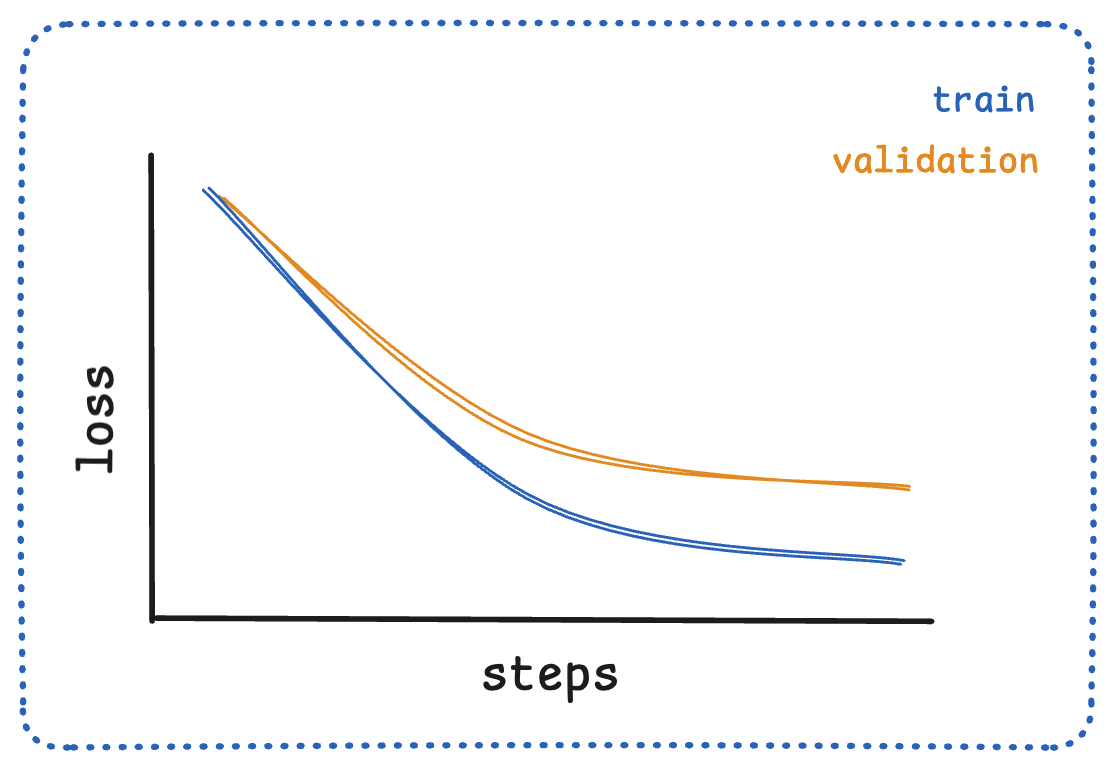

* **High initial loss:** The model starts without optimization, so predictions are initially poor

* **Decreasing loss:** As training progresses, the loss should generally decrease

* **Convergence:** Eventually, the loss stabilizes at a low value, indicating that the model has learned the patterns in the data

We can use the `Trainer` API to track these `metrics` and visualize them in a dashboard. Below is an example of how to do this with **Weights & Biases.**

In [ ]:
# Example of tracking loss during training with the Trainer
from transformers import Trainer, TrainingArguments
import wandb

# Initialize Weights & Biases for experiment tracking
wandb.init(project="transformer-fine-tuning", name="bert-mrpc-analysis")

training_args = TrainingArguments(
    output_dir="./results",  # where to save model checkpoints
    eval_strategy="steps",   # evaluate every N steps (not every epoch)
    eval_steps=50,           # run evaluation every 50 steps
    save_steps=100,          # save model checkpoint every 100 steps
    logging_steps=10,        # log loss/metrics every 10 steps
    num_train_epochs=3,      # train for 3 full passes over the dataset
    per_device_train_batch_size=16,   # 16 samples per batch during training
    per_device_eval_batch_size=16,    # 16 samples per batch during evaluation
    # report_to="wandb",   # send all logs to Weights & Biases dashboard

    report_to="none"   # set as None as we need to create account for wandb for visualisation and all....
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# Train and automatically log metrics
trainer.train()

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

#### Accuracy Curves :-

The accuracy curve shows the percentage of correct predictions over time. Unlike loss curves, accuracy curves should generally increase as the model learns and can typically include more steps than the loss curve. 

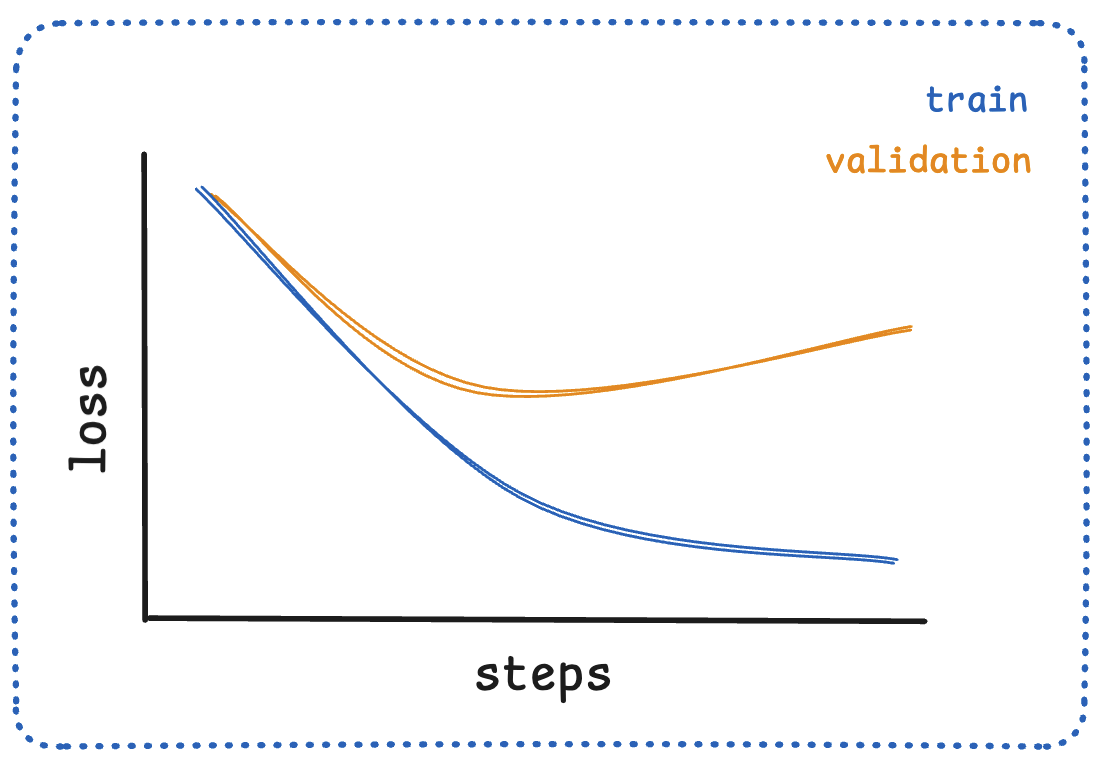

* **Start low:** Initial accuracy should be low, as the model has not yet learned the patterns in the data

* **Increase with training:** Accuracy should generally improve as the model learns if it is able to learn the patterns in the data

* **May show plateaus:** Accuracy often increases in discrete jumps rather than smoothly, as the model makes predictions that are close to the true labels

#### Convergence :-

Convergence occurs when the model’s performance stabilizes and the loss and accuracy curves level off. This is a sign that the model has learned the patterns in the data and is ready to be used. In simple terms, we are aiming for the model to converge to a stable performance every time we train it.

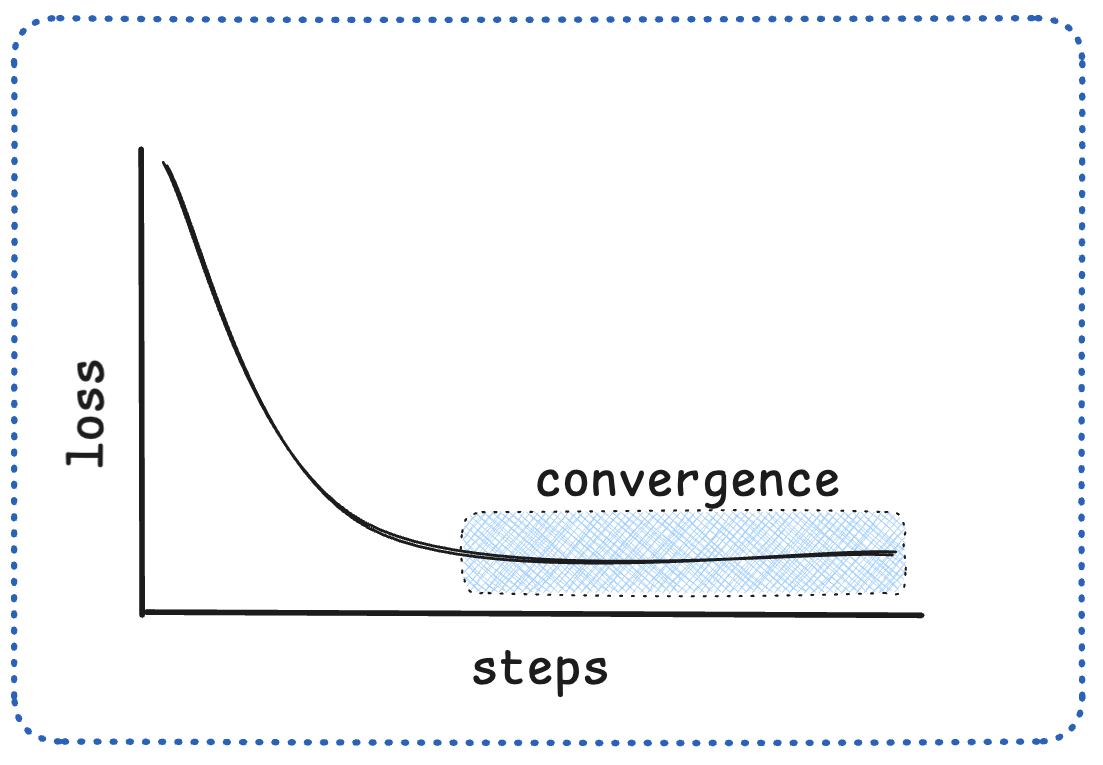

Once models have converged, we can use them to make predictions on new data and refer to evaluation metrics to understand how well the model is performing.

### Interpreting Learning Curve Patterns :-

Different curve shapes reveal different aspects of your model’s training. Let’s examine the most common patterns and what they mean.

#### Healthy Learning Curves :-

A well-behaved training run typically shows curve shapes similar to the one below:

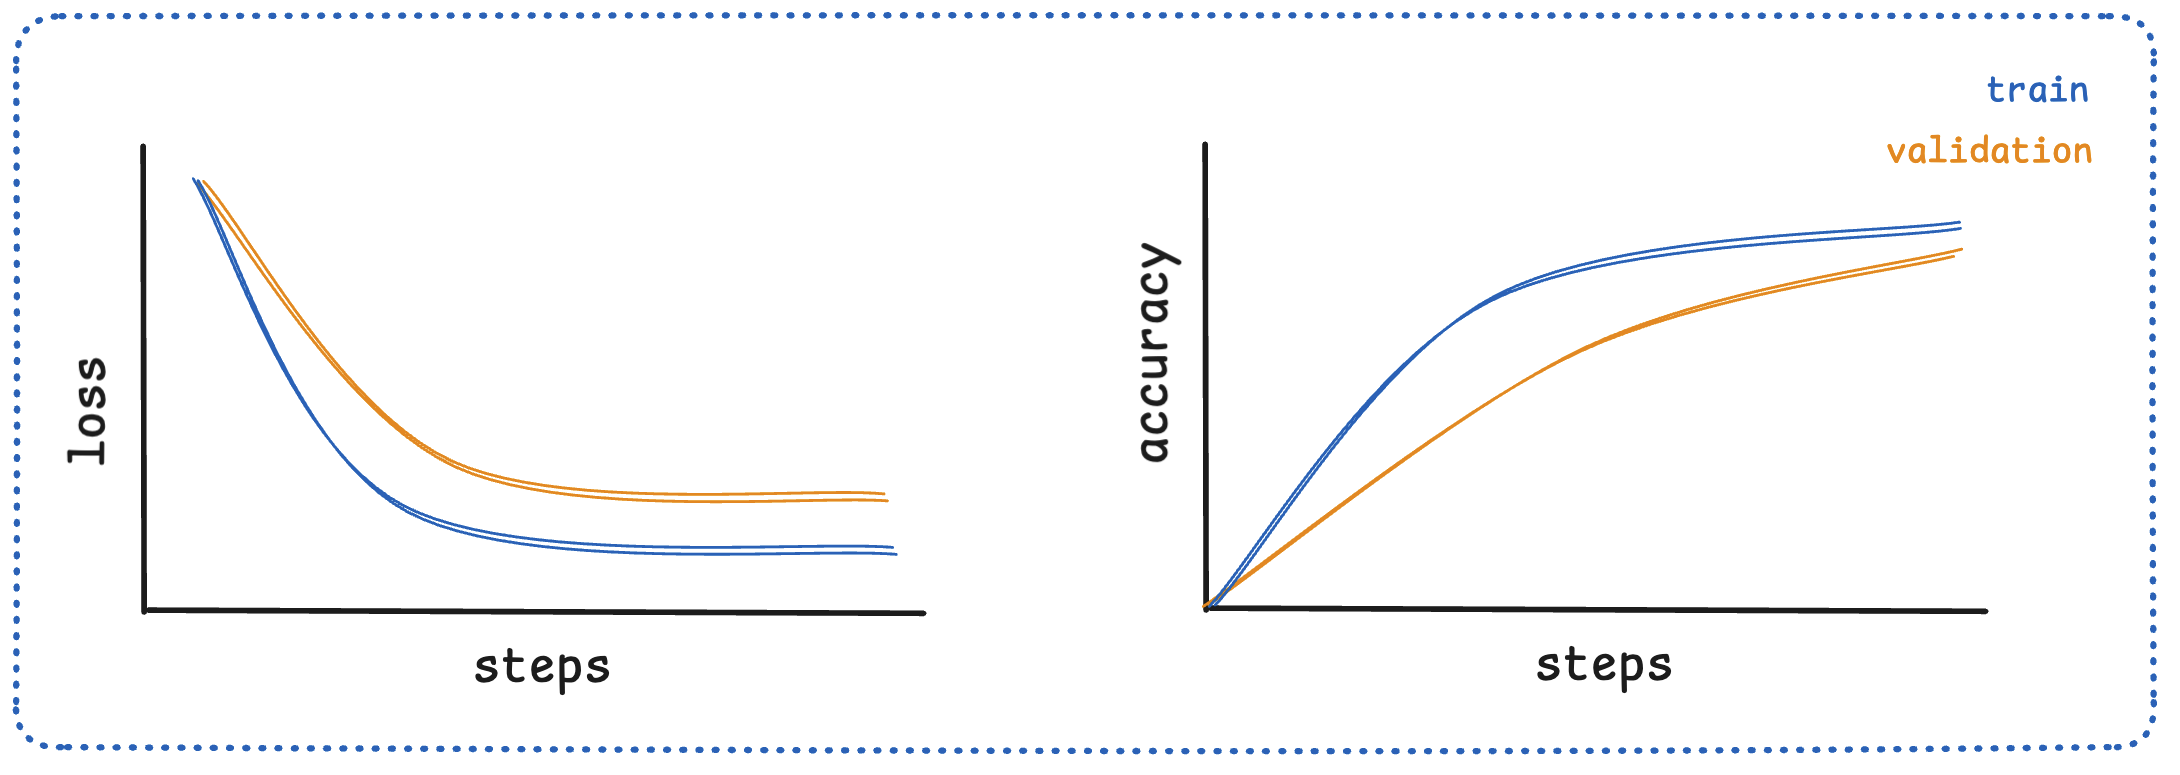

Let’s look at the illustration above. It displays both the loss curve (on the left) and the corresponding accuracy curve (on the right). These curves have distinct characteristics.

The loss curve shows the value of the model’s loss over time. Initially, the loss is high and then it gradually decreases, indicating that the model is improving. A decrease in the loss value suggests that the model is making better predictions, as the loss represents the error between the predicted output and the true output.

Now let’s shift our focus to the accuracy curve. It represents the model’s accuracy over time. The accuracy curve begins at a low value and increases as training progresses. Accuracy measures the proportion of correctly classified instances. So, as the accuracy curve rises, it signifies that the model is making more correct predictions.

One notable difference between the curves is the smoothness and the presence of “plateaus” on the accuracy curve. While the loss decreases smoothly, the plateaus on the accuracy curve indicate discrete jumps in accuracy instead of a continuous increase. This behavior is attributed to how accuracy is measured. The loss can improve if the model’s output gets closer to the target, even if the final prediction is still incorrect. Accuracy, however, only improves when the prediction crosses the threshold to be correct.

For example, in a binary classifier distinguishing cats (0) from dogs (1), if the model predicts 0.3 for an image of a dog (true value 1), this is rounded to 0 and is an incorrect classification. If in the next step it predicts 0.4, it’s still incorrect. The loss will have decreased because 0.4 is closer to 1 than 0.3, but the accuracy remains unchanged, creating a plateau. The accuracy will only jump up when the model predicts a value greater than 0.5 that gets rounded to 1.

**Characteristics of healthy curves:**

* **Smooth decline in loss:** Both training and validation loss decrease steadily

* **Close training/validation performance:** Small gap between training and validation metrics

* **Convergence:** Curves level off, indicating the model has learned the patterns

### Practical Examples :-

Let’s work through some practical examples of learning curves. First, we will highlight some approaches to monitor the learning curves during training. Below, we will break down the different patterns that can be observed in the learning curves.

#### During Training :-

During the training process (after you’ve hit `trainer.train()`), you can monitor these key indicators:

1. **Loss convergence:** Is the loss still decreasing or has it plateaued?

2. **Overfitting signs:** Is validation loss starting to increase while training loss decreases?

3. **Learning rate:** Are the curves too erratic (LR too high) or too flat (LR too low)?

4. **Stability:** Are there sudden spikes or drops that indicate problems?

#### After Training :-

After the training process is complete, you can analyze the complete curves to understand the model’s performance.

1. **Final performance:** Did the model reach acceptable performance levels?

2. **Efficiency:** Could the same performance be achieved with fewer epochs?

3. **Generalization:** How close are training and validation performance?

4. **Trends:** Would additional training likely improve performance?

**🔍 W&B Dashboard Features:** Weights & Biases automatically creates beautiful, interactive plots of your learning curves. You can:

* Compare multiple runs side by side

* Add custom metrics and visualizations

* Set up alerts for anomalous behavior

* Share results with your team

#### Overfitting :-

Overfitting occurs when the model learns too much from the training data and is unable to generalize to different data (represented by the validation set).

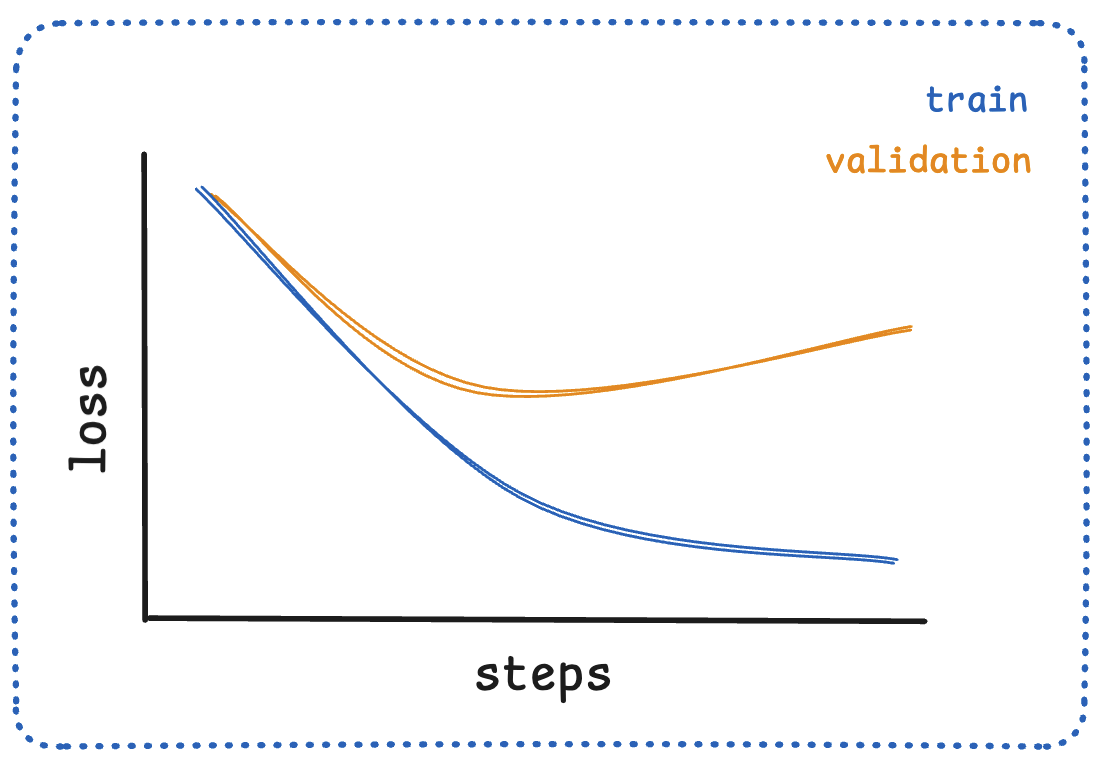

**Symptoms:**

* Training loss continues to decrease while validation loss increases or plateaus

* Large gap between training and validation accuracy

* Training accuracy much higher than validation accuracy

**Solutions for overfitting:**

* `Regularization:` Add dropout, weight decay, or other regularization techniques

* `Early stopping:` Stop training when validation performance stops improving
 
* `Data augmentation:` Increase training data diversity

* `Reduce model complexity:` Use a smaller model or fewer parameters

In the sample below, we use `early stopping` to **prevent overfitting**. We set the `early_stopping_patience` to `3`, which means that if the validation loss does not improve for 3 consecutive epochs, the training will be stopped.

In [ ]:
# Example of detecting overfitting with early stopping
from transformers import EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,        # after validation loss stops improving, load the best checkpoint instead of the last one
    metric_for_best_model="eval_loss",  # use validation loss to determine which checkpoint is "best"
    greater_is_better=False,            # lower eval_loss is better (so False, we want to minimize it)
    num_train_epochs=10,
)

# Add early stopping to prevent overfitting
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

#### 2. Underfitting :-

Underfitting occurs when the model is too simple to capture the underlying patterns in the data. This can happen for several reasons:

* The model is too small or lacks capacity to learn the patterns

* The learning rate is too low, causing slow learning

* The dataset is too small or not representative of the problem

* The model is not properly regularized

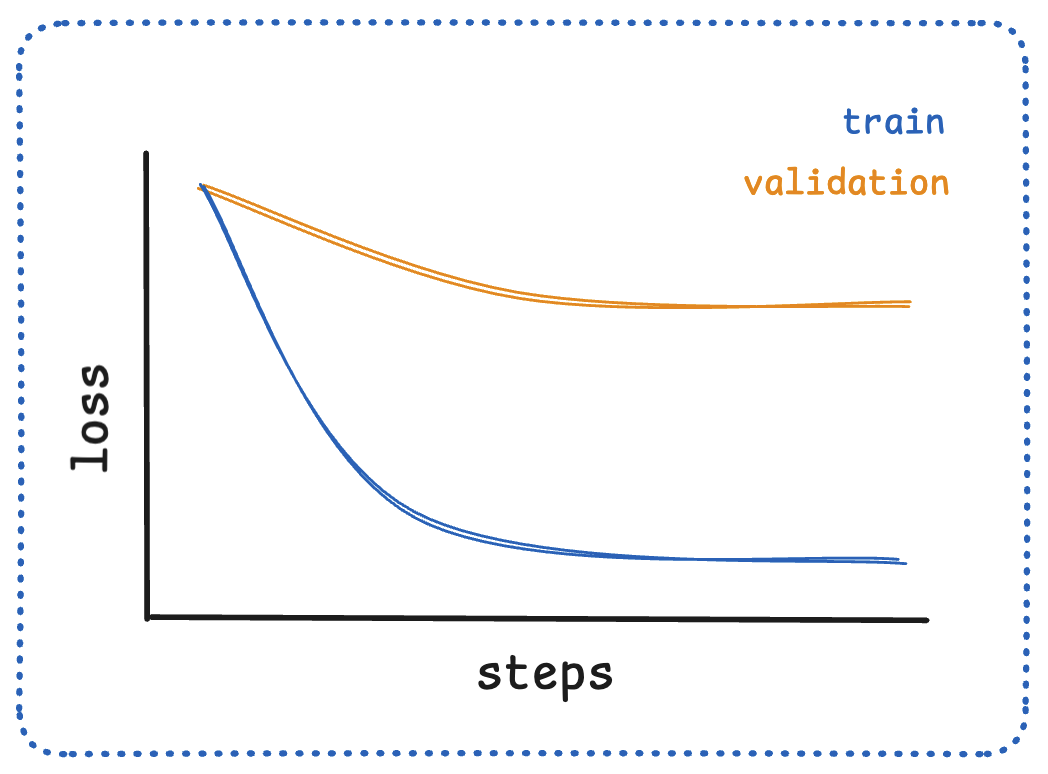

**Symptoms:**

* Both training and validation loss remain high

* Model performance plateaus early in training

* Training accuracy is lower than expected

**Solutions for underfitting:**

* **Increase model capacity:** Use a larger model or more parameters

* **Train longer:** Increase the number of epochs

* **Adjust learning rate:** Try different learning rates

* **Check data quality:** Ensure your data is properly preprocessed

#### 3. Erratic Learning Curves :-

Erratic learning curves occur when the model is not learning effectively. This can happen for several reasons:

* The learning rate is too high, causing the model to overshoot the optimal parameters

* The batch size is too small, causing the model to learn slowly

* The model is not properly regularized, causing it to overfit to the training data

* The dataset is not properly preprocessed, causing the model to learn from noise

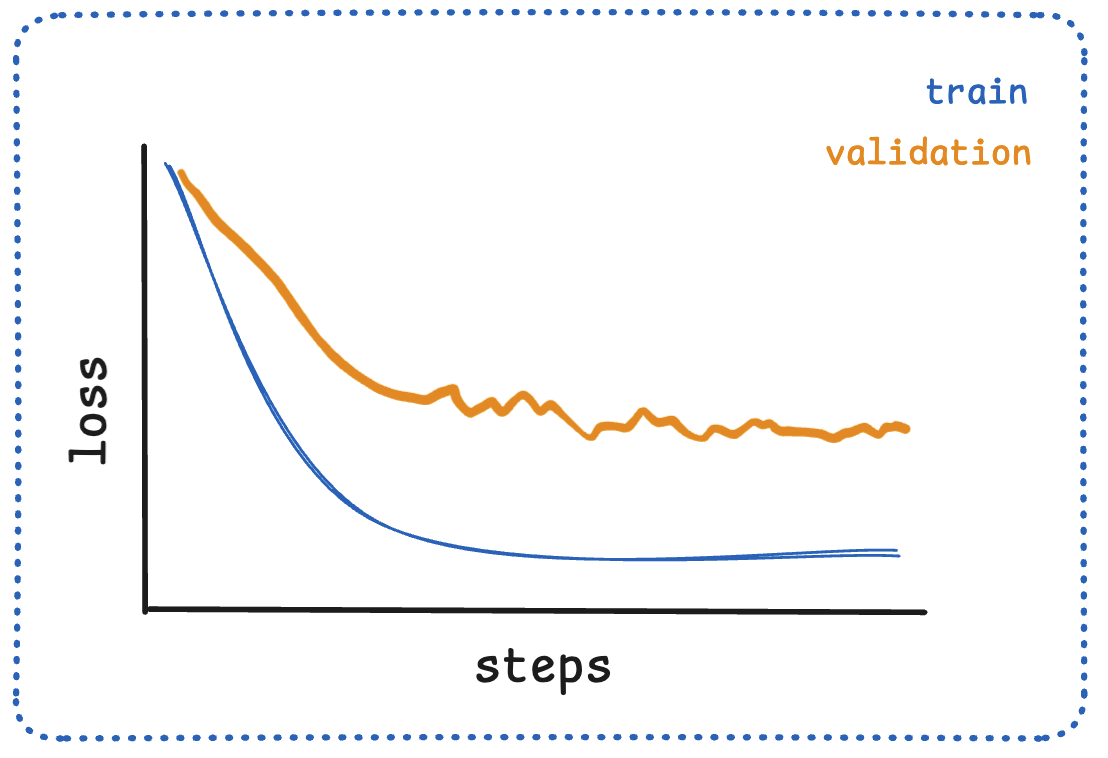

**Symptoms:**

* Frequent fluctuations in loss or accuracy

* Curves show high variance or instability

* Performance oscillates without clear trend

Both training and validation curves show erratic behavior.

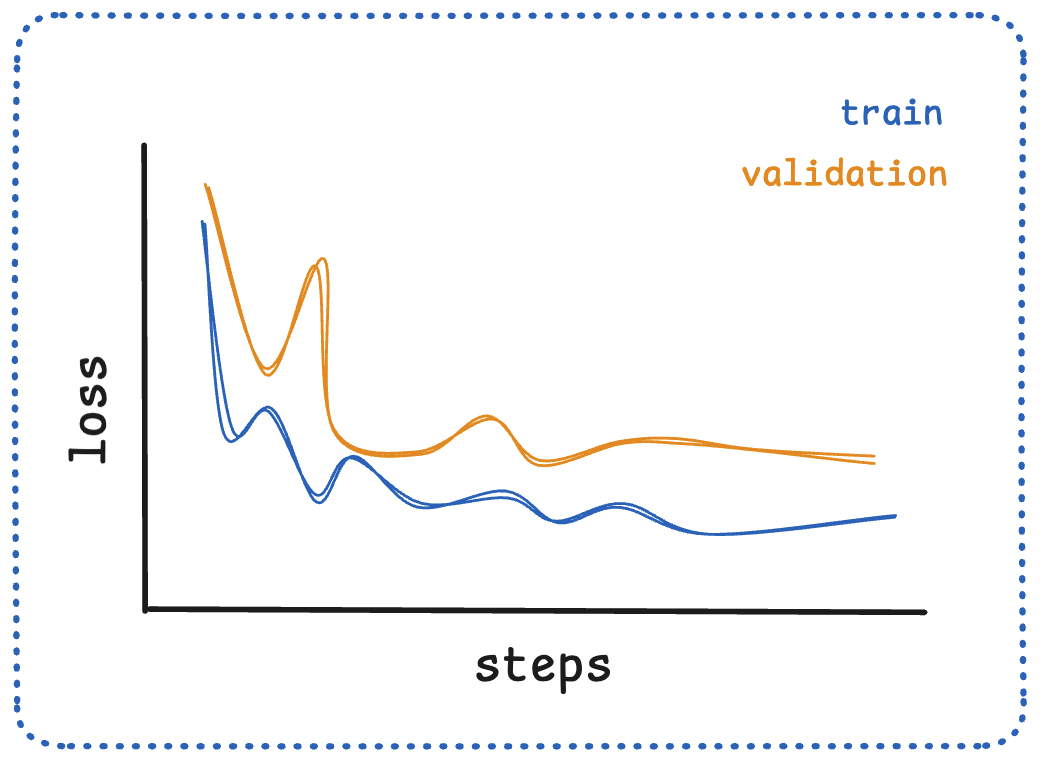

**Solutions for erratic curves:**

* **Lower learning rate:** Reduce step size for more stable training

* **Increase batch size:** Larger batches provide more stable gradients

* **Gradient clipping:** Prevent exploding gradients

* **Better data preprocessing:** Ensure consistent data quality

### Key Takeaways :-

Understanding learning curves is crucial for becoming an effective machine learning practitioner. These visual tools provide immediate feedback about your model’s training progress and help you make informed decisions about when to stop training, adjust hyperparameters, or try different approaches. With practice, you’ll develop an intuitive understanding of what healthy learning curves look like and how to address issues when they arise.